# Reading provenance directly
The processed RO-Crates contain a new directory with provenance data
We can extract provenance data directly without reading Galaxy entities:
```
exp_crate/
|-- datasets/
|   |-- ds_001.xxx
|   `-- ...
|-- provenance/
|   |-- galaxy_run_prov.jsonld
|   |-- galaxy_run_prov.ttl
|   `-- ...
|-- workflow/
|--ro-crate-metadata.json
...        

In [1]:
# using rocrate
from rocrate.rocrate import ROCrate
from pathlib import Path

# defined functions to get data from RO-Crate
from read_provenance import *

file_name = "FeS2-Analysis.rocrate.prov.zip"

file_path = Path("./result_roc", file_name)

crate = ROCrate(file_path)
data_entities = []
for e in crate.get_entities():
    if "provenance/data" in e.id:
        print(e.id, e.type)
        data_entities.append(e.id)
        

C:\Users\scman1\AppData\Roaming\Python\Python39\site-packages\rocrate\vocabs.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


provenance/dataset_df0bac1ee137448a.jsonld File
provenance/dataset_df02c7af9dfe5b62.jsonld File
provenance/dataset_d49ffa4044c67d15.jsonld File
provenance/dataset_6c2ea4582a260280.jsonld File
provenance/dataset_409c0d24534294d8.jsonld File
provenance/dataset_a38f4b5b93cd4e1a.jsonld File
provenance/dataset_a011be860e2a8b79.jsonld File
provenance/dataset_547228271cdb66e2.jsonld File
provenance/dataset_75738551921d866c.jsonld File
provenance/dataset_c3e4da2bb600d6e3.jsonld File
provenance/dataset_a9305118c6acc078.jsonld File
provenance/dataset_fb5bc774c9b03fce.jsonld File


In [2]:
f = get_file_from_rocratezip(file_path, data_entities[0])
details = json.load(f)

In [3]:
print(json.dumps(details, indent=4))

{
    "@context": {
        "cdif4xaz": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-4-XAS#",
        "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
        "dcterms": "http://purl.org/dc/terms/",
        "ex": "http://example.org#",
        "panet": "http://purl.org/pan-science/PaNET/",
        "prov": "http://www.w3.org/ns/prov#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "schema": "https://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
    },
    "@id": "dataset_df0bac1ee137448a.jsonld",
    "@type": [
        "prov:Entity",
        "cdifprov:Dataset",
        "schema:MediaObject",
        "schema:CreativeWork"
    ],
    "dcterms:description": "uploaded txt file",
    "dcterms:format": "text/plain",
    "dcterms:subject": [
        {
            "@id": "panet:PaNET01196"
        },
        {
            "@id": "ex:Le

In [4]:
def get_roc_provenance(roc_file):
    roc_graph = Graph()
    f = get_file_from_rocratezip(roc_file, "provenance/galaxy_run_prov.jsonld")
    json_roc = json.load(f)
    roc_graph.parse(
        data=json.dumps(json_roc),
        format="json-ld",publicID="/"
    )
    roc_graph = fix_graph_root(roc_graph)
    return roc_graph
    
def fix_graph_root(a_graph):
    new_graph = Graph()
    
    for s, p, o in a_graph:    
        if isinstance(s, URIRef) and str(s).startswith("file:///"):
            s = URIRef(str(s).replace("file://", "", 1))
        if isinstance(o, URIRef) and str(o).startswith("file:///"):
            o = URIRef(str(o).replace("file://", "", 1))
        new_graph.add((s, p, o))
    return new_graph

an_roc_graph = get_roc_provenance(file_path)

In [5]:
#get datasets provenance from the roc graph
datasets_provenance = get_datasets_prov(an_roc_graph)
display(HTML(datasets_provenance.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,fes2_rt01_mar02.xmu,None
1,/step/1,fetch data from history,DATA_FETCH,1564889.cif,None
2,/step/2,process and normalise XAS,larch_athena,FeS2_athena,fes2_rt01_mar02.xmu
3,/step/2,process and normalise XAS,larch_athena,FeS2_plot,fes2_rt01_mar02.xmu
4,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF input of 1564889.cif,1564889.cif
5,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF paths of 1564889.cif,1564889.cif
6,/step/3,calculate FEFF paths from crystal,larch_feff,CSV summary of 1564889.cif,1564889.cif
7,/step/4,select FEFF paths,larch_select_paths,fes2_sp,"CSV summary of 1564889.cif, FEFF paths of 1564889.cif"
8,/step/4,select FEFF paths,larch_select_paths,fes2_gds,"CSV summary of 1564889.cif, FEFF paths of 1564889.cif"
9,/step/5,FEFF fit of XAS,larch_artemis,rmr_FeS2,"FeS2_athena, fes2_gds, FEFF paths of 1564889.cif, fes2_sp"


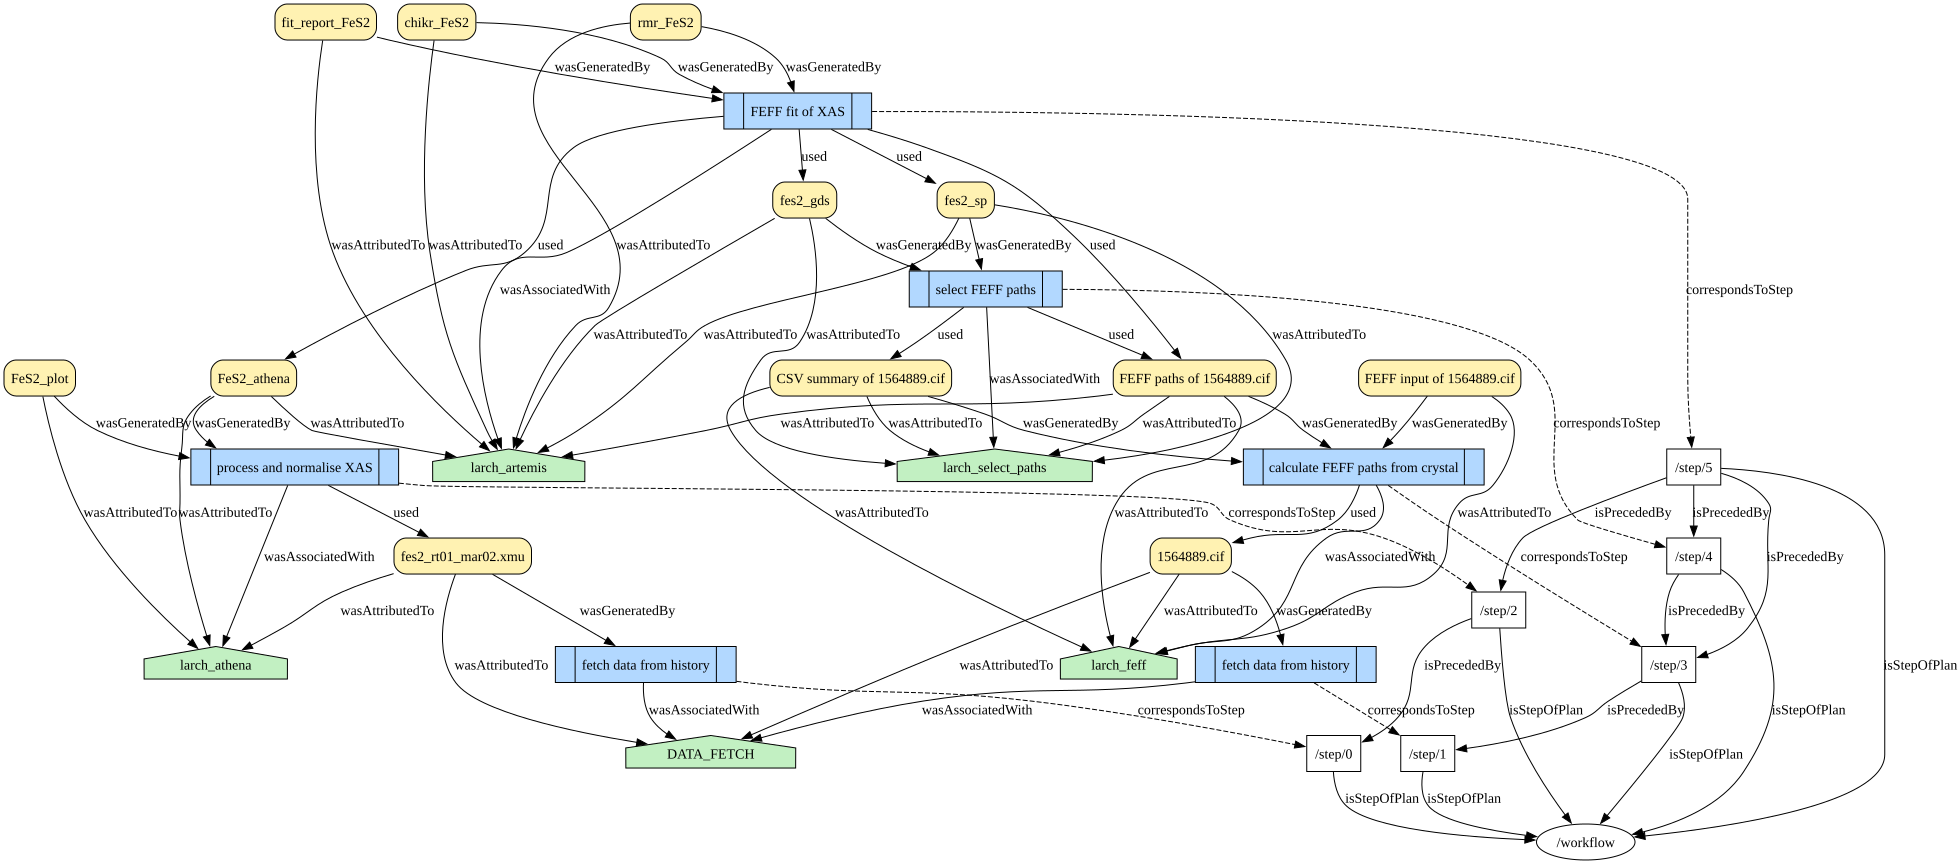

In [6]:
#plan_dot = draw_prov_only(an_roc_graph)
#display(plan_dot)

#plan_dot = draw_pplan_only(an_roc_graph)
#display(plan_dot)

fullprov_dot = draw_prov_full(an_roc_graph)
display(fullprov_dot)

In [7]:
ds_jsons = show_datasets(an_roc_graph, output_path = "", show_only = True)

,Property,Value
0,dcterms:format,text/plain
1,rdf:type,prov:Entity
2,rdf:type,schema:MediaObject
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,skos:prefLabel,fes2_rt01_mar02.xmu
5,prov:wasAttributedTo,larch_athena
6,prov:wasAttributedTo,DATA_FETCH
7,schema:id,datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt
8,prov:wasGeneratedBy,fetch data from history
9,dcterms:description,uploaded txt file


,Property,Value
0,dcterms:description,"Metadata is limited as the Atomic Simulation Environment (ASE) is not installed.You can still use this dataset in tools and workflows.For full metadata, ask your admin to install the 'ase' Python package."
1,rdf:type,schema:MediaObject
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
3,rdf:type,prov:Entity
4,prov:wasAttributedTo,DATA_FETCH
5,prov:wasAttributedTo,larch_feff
6,dcterms:format,chemical/x-cif
7,schema:id,datasets/1564889.cif_df02c7af9dfe5b62.cif
8,skos:prefLabel,1564889.cif
9,prov:wasGeneratedBy,fetch data from history


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,schema:MediaObject
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
3,prov:wasAttributedTo,larch_athena
4,prov:wasAttributedTo,larch_artemis
5,schema:id,datasets/FeS2_athena_d49ffa4044c67d15.prj
6,prov:wasGeneratedBy,process and normalise XAS
7,dcterms:description,atsym: Febkg_e0: 7117.0edge: Knpts: 352xmax: 7963.5xmin: 6911.8
8,skos:prefLabel,FeS2_athena
9,dcterms:format,application/vnd.demeter.athena


,Property,Value
0,schema:id,datasets/FeS2_plot_6c2ea4582a260280.png
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
2,rdf:type,prov:Entity
3,rdf:type,schema:MediaObject
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
5,dcterms:format,image/png
6,skos:prefLabel,FeS2_plot
7,dcterms:description,"Attempting to read from /mnt/nfs/data/f/6/4/dataset_f640df2f-ce68-4309-bc83-2e052fb749f1.datRead columns: ['energy', 'xmu', 'i0']'energy' present in column headersRenaming columns to: ['energy', 'mu', 'i0']Cannot load group.athena_params.bkg from gro"
8,prov:wasGeneratedBy,process and normalise XAS
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,prov:Entity
2,rdf:type,schema:MediaObject
3,prov:wasGeneratedBy,calculate FEFF paths from crystal
4,prov:wasAttributedTo,larch_feff
5,dcterms:description,Formula: FeS2SpaceGroup: Pnnm# sites: 6
6,schema:id,datasets/FEFF_input_of_1564889.cif_409c0d24534294d8.inp
7,skos:prefLabel,FEFF input of 1564889.cif
8,dcterms:format,chemical/x-feff-input
9,dcterms:subject,<http://purl.org/pan-science/PaNET/PaNET01082>


...

,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,prov:Entity
2,rdf:type,schema:MediaObject
3,skos:prefLabel,fes2_sp
4,prov:wasGeneratedBy,select FEFF paths
5,schema:id,datasets/fes2_sp_75738551921d866c.sp
6,dcterms:description,
7,prov:wasAttributedTo,larch_select_paths
8,prov:wasAttributedTo,larch_artemis
9,dcterms:format,text/csv


,Property,Value
0,prov:wasAttributedTo,larch_select_paths
1,prov:wasAttributedTo,larch_artemis
2,rdf:type,prov:Entity
3,rdf:type,schema:MediaObject
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,dcterms:description,
6,prov:wasGeneratedBy,select FEFF paths
7,dcterms:format,text/csv
8,schema:id,datasets/fes2_gds_547228271cdb66e2.gds
9,skos:prefLabel,fes2_gds


,Property,Value
0,prov:wasGeneratedBy,FEFF fit of XAS
1,rdf:type,schema:MediaObject
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,rdf:type,prov:Entity
5,skos:prefLabel,rmr_FeS2
6,dcterms:format,image/png
7,schema:id,datasets/rmr_FeS2_fb5bc774c9b03fce.png
8,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
9,prov:wasAttributedTo,larch_artemis


,Property,Value
0,schema:id,datasets/chikr_FeS2_c3e4da2bb600d6e3.png
1,dcterms:format,image/png
2,rdf:type,prov:Entity
3,rdf:type,schema:MediaObject
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
5,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
6,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
7,prov:wasAttributedTo,larch_artemis
8,prov:wasGeneratedBy,FEFF fit of XAS
9,skos:prefLabel,chikr_FeS2


,Property,Value
0,schema:id,datasets/fit_report_FeS2_a9305118c6acc078.feffit
1,rdf:type,schema:MediaObject
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
3,rdf:type,prov:Entity
4,prov:wasGeneratedBy,FEFF fit of XAS
5,skos:prefLabel,fit_report_FeS2
6,dcterms:format,text/plain
7,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
8,prov:wasAttributedTo,larch_artemis
9,dcterms:subject,<http://purl.org/pan-science/PaNET/PaNET01197>


In [8]:
from collections import Counter
from rdflib import RDF, Namespace

PROV = Namespace("http://www.w3.org/ns/prov#")
entities = set(an_roc_graph.subjects(RDF.type, PROV.Entity))

types = Counter()
formats = Counter()
subjects = Counter()
for e in entities:
    # entity types
    for t in an_roc_graph.objects(e, RDF.type):
        if t != PROV.Entity:
            types[str(t).split("/")[-1]] += 1

    # file formats
    for f in an_roc_graph.objects(e, DCTERMS.format):
        formats[str(f)] += 1

    # file subjects
    #for d in an_roc_graph.objects(e, DCTERMS.description):
        #print("*"*80)
        #print(e)
        #print(d)
        #subjects[str(s)] += 1

print("Total datasets:", len(entities))

print("\nTypes")
for k, v in types.most_common():
    print(f"{k}: {v}")

print("\nFormats")
for k, v in formats.most_common():
    print(f"{k}: {v}")
    
print("\nSubjects")
for k, v in subjects.most_common():
    print(f"{k}: {v}")

Total datasets: 12

Types
MediaObject: 12
CDIF-PROV#Dataset: 12
CDIF-PROV#DataProduct: 3

Formats
text/csv: 3
image/png: 3
text/plain: 2
chemical/x-cif: 1
chemical/x-feff-input: 1
application/zip: 1
application/vnd.demeter.athena: 1

Subjects


In [9]:
# now read it from json-lds of datasets
# assing processing levels using sweet

inv = get_roc_json_part(file_path, data_entities[3])
print(json.dumps(inv, indent=4))

{
    "@context": {
        "cdif4xaz": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-4-XAS#",
        "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
        "dcterms": "http://purl.org/dc/terms/",
        "ex": "http://example.org#",
        "panet": "http://purl.org/pan-science/PaNET/",
        "prov": "http://www.w3.org/ns/prov#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "schema": "https://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
    },
    "@id": "dataset_6c2ea4582a260280.jsonld",
    "@type": [
        "prov:Entity",
        "cdifprov:Dataset",
        "cdifprov:DataProduct",
        "schema:MediaObject",
        "schema:CreativeWork"
    ],
    "dcterms:description": "\nAttempting to read from /mnt/nfs/data/f/6/4/dataset_f640df2f-ce68-4309-bc83-2e052fb749f1.dat\nRead columns: ['energy', 'xmu', 'i0']\n'energy'

In [10]:
def get_panet_entities():
    full_graph = Graph()
    full_graph.parse("resources/panet.ttl")
    reduced_lookup = Graph()
    for an_id in PANET_IDS.values():
        for a_triple in full_graph.triples((an_id, None, None)):
            reduced_lookup.add(a_triple)
    return reduced_lookup

small_graph = Graph()
#small_graph = get_panet_entities()
small_graph.parse("resources/panent_fragment.ttl")
small_graph.parse("resources/sweet-pl.ttl") 
for an_ent in data_entities:
    inv = get_roc_json_part(file_path, an_ent)
    small_graph.parse(
            data=json.dumps(inv),
            format="json-ld",publicID="/"
        )
    break
small_graph = fix_graph_root(small_graph)

In [11]:
nx_graph = rdflib_to_networkx_graph(small_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 50 nodes and 40 edges loaded successfully
nx.html


In [12]:
save_graph = get_panet_entities()
# save reduced panet ontology (only used clasess)
# save_graph.serialize(destination="resources/panent_fragment.ttl", format="ttl")

In [48]:
# This is how individual dataset JSON files are generated
for ds_entity in entities:
    ds_properties = get_dataset_properties(ds_entity, an_roc_graph)
    ds_properties = add_panet_class(ds_entity, ds_properties, an_roc_graph)
    ds_properties = add_processing_level(ds_entity, ds_properties, an_roc_graph)
    ds_properties = add_ancestor(ds_entity, ds_properties, an_roc_graph)
    print(ds_properties)
    break

[[rdflib.term.URIRef('https://schema.org/id'), rdflib.term.Literal('datasets/fit_report_FeS2_a9305118c6acc078.feffit')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://schema.org/MediaObject')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://www.w3.org/ns/prov#Entity')], [rdflib.term.URIRef('http://www.w3.org/ns/prov#wasGeneratedBy'), rdflib.term.URIRef('/run/cf423d990ba14fcd')], [rdflib.term.URIRef('http://www.w3.org/2004/02/skos/core#prefLabel'), rdflib.term.Literal('fit_report_FeS2')], [rdflib.term.URIRef('http://purl.org/dc/terms/format'), rdflib.term.Literal('text/plain')], [rdflib.term.URIRef('http://purl.org/dc/terms/description'), rdflib.term.Literal('\nArchive:  /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-

In [14]:
for a_key in ["element", "e0", "edge", "sample_name", "sample_formula"]:
    pred = CDIF4XAS[a_key]
    print (pred)

https://worldfair-project.eu/cdif/profiles/provenance/CDIF-4-XAS#element
https://worldfair-project.eu/cdif/profiles/provenance/CDIF-4-XAS#e0
https://worldfair-project.eu/cdif/profiles/provenance/CDIF-4-XAS#edge
https://worldfair-project.eu/cdif/profiles/provenance/CDIF-4-XAS#sample_name
https://worldfair-project.eu/cdif/profiles/provenance/CDIF-4-XAS#sample_formula


In [75]:
def get_ancestors(graph, entity):
    seen = set()
    stack = [entity]
    while stack:
        current = stack.pop()
        for activity in graph.objects(current, PROV.wasGeneratedBy):
            for parent in graph.objects(activity, PROV.used):
                if parent not in seen:
                    seen.add(parent)
                    stack.append(parent)
    return seen

def get_descendants(graph, entity):
    seen = set()
    stack = [entity]
    while stack:
        current = stack.pop()
        for activity in graph.subjects(PROV.used, current):
            for child in graph.subjects(
                PROV.wasGeneratedBy,
                activity
            ):
                if child not in seen:
                    seen.add(child)
                    stack.append(child)

    return seen

def get_full_ancestry(a_graph, an_entity):
    all_ancestors = get_ancestors(a_graph, an_entity)
    all_descendants = get_descendants(a_graph, an_entity)
    return {"entity": an_entity, "ancestors": all_ancestors, "descendants": all_descendants}

def get_values_custom_xmu_textfile(file_path, filename):
    f = get_file_from_rocratezip(file_path, filename)
    return_dict = {}
    for line in f:
        text = line.decode('utf-8')
        if text[0] == "#":
            if "#%name:" in text: 
                #print(f"name: {text[7:].strip()}")
                return_dict["sample_name"] = text[7:].strip()
            elif "#%atom:" in text: 
                #print(f"Sample: {text[7:].strip()}")
                return_dict["sample_formula"] = text[7:].strip()
            elif "#%edge:" in str(line): 
                #print(f"Edge: {text[7:].strip()}")
                return_dict["edge"] = text[7:].strip()
            elif "#%temp:" in str(line): 
                #print(f"Temperature: {text[7:].strip()}")
                return_dict["temperature"] = text[7:].strip()
            elif "#%beam:" in str(line): 
                #print(f"Beamline: {text[7:].strip()}")
                return_dict["beamline"] = text[7:].strip()
        else:
          break
    return return_dict

def get_entity_type(graph_thing, an_entity):
    for a_type in graph_thing.objects(an_entity, DCTERMS.format):
        return a_type

def get_entity_path(graph_thing, an_entity):
    for a_path in graph_thing.objects(an_entity, SCHEMA.id):
        return a_path

def get_entity_description(graph_thing, an_entity):
    for a_desc in graph_thing.objects(an_entity, DCTERMS.description):
        return a_desc

def get_entity_metadata(roc_path, graph_thing, an_entity):
    a_type = str(get_entity_type(graph_thing, an_entity))
    
    vals_entity = {}
    print (get_a_label(graph_thing, an_entity), '->', a_type)
    # text types
    if a_type in ["text/plain", "chemical/x-cif", 
                  "text/csv", "application/xdi"]:
        filename = str(get_entity_path(graph_thing, an_entity))
        #print (get_a_label(graph_thing, an_entity)[-4:])
        if get_a_label(graph_thing, an_entity)[-4:] == ".xmu":
        #    print("getting xmu metadata")
            vals_entity = get_values_custom_xmu_textfile(roc_path, filename)
        # need other methods for xdi and dat files from different beamlines
    elif a_type in ["application/vnd.demeter.athena"]:
        # athena project files
        entity_desc = get_entity_description(graph_thing, an_entity)
        vals_entity = get_values_athena_project(entity_desc)
    return vals_entity


def get_values_athena_project(athena_descr):
    athena_split = athena_descr.split("\n")
    return_dict = {}
    for a_line in athena_split:
        [k,v] = a_line.split(": ")
        if k == "atsym":
             k =  "element"
        elif k == 'bkg_e0':
            k = "e0"
        elif k == 'npts':
            k = "points"
        elif k == 'xmax':
            k = 'energy_max'
        elif k == 'xmin':
            k = 'energy_min'
        return_dict[k] = v 
    return return_dict

the_entity  = (list(entities)[11])
entity_ancestry = get_full_ancestry(an_roc_graph, the_entity)
#print( get_a_label(an_roc_graph, the_entity))
#print("*** Ancestors ***")
#for an_ancestor in entity_ancestry["ancestors"]:
#    print(get_a_label(an_roc_graph, an_ancestor))
#print("*** Descendants ***")
#for a_descendant in entity_ancestry["descendants"]: 
#    print (get_a_label(an_roc_graph, a_descendant))

# check if entities in ancestry are txt or athena prj
#a_type = str(get_entity_type(an_roc_graph, the_entity))

#vals_entity = {}
#if a_type in ["text/plain", "chemical/x-cif", 
#              "text/csv", "application/xdi"]:
#    # text types
#    print (get_a_label(an_roc_graph, the_entity), '->', a_type)
#    filename = str(get_entity_path(an_roc_graph, the_entity))
#    print (get_a_label(an_roc_graph, the_entity)[-4:])
#    if get_a_label(an_roc_graph, the_entity)[-4:] == ".xmu":
#        print("getting xmu metadata")
#        vals_entity = get_values_custom_xmu_textfile(file_path, filename)
#    # need other methods for xdi and dat files from different beamlines
#elif a_type in ["application/vnd.demeter.athena"]:
#    # athena project files
#    print (get_a_label(an_roc_graph, the_entity), '->', a_type)
#    entity_desc = get_entity_description(an_roc_graph, the_entity)
#    vals_entity = get_values_athena_project(entity_desc)


branch_metadata = {}
branch_metadata[entity_ancestry["entity"]] = get_entity_metadata(file_path, an_roc_graph, entity_ancestry["entity"])


for an_ancestor in entity_ancestry["ancestors"]:
    branch_metadata[an_ancestor] = get_entity_metadata(file_path, an_roc_graph, an_ancestor)

vals_descendants = {}
for a_descendant in entity_ancestry["descendants"]:
    branch_metadata[a_descendant] = get_entity_metadata(file_path, an_roc_graph, a_descendant)

print (branch_metadata)

# for the first case is OK to join them all

sinlge_metadata = {}
for an_entity in branch_metadata:
    if branch_metadata[an_entity] != {}:
        sinlge_metadata = sinlge_metadata|branch_metadata[an_entity]

print(sinlge_metadata)

# actual metadata pairs
branch_prov_metadata = [] 
for a_key in sinlge_metadata:
        if a_key in ["element", "e0", "edge", "sample_name", 
                     "sample_formula", "beamline"]:
            pred = CDIF4XAS[a_key]
            branch_prov_metadata.append([pred, sinlge_metadata[a_key]])

print(branch_prov_metadata)


FeS2_athena -> application/vnd.demeter.athena
fes2_rt01_mar02.xmu -> text/plain
chikr_FeS2 -> image/png
fit_report_FeS2 -> text/plain
rmr_FeS2 -> image/png
{rdflib.term.URIRef('/dataset/d49ffa4044c67d15'): {'element': 'Fe', 'e0': '7117.0', 'edge': 'K', 'points': '352', 'energy_max': '7963.5', 'energy_min': '6911.8'}, rdflib.term.URIRef('/dataset/df0bac1ee137448a'): {'sample_name': 'FeS2 powder  Room Temperature', 'sample_formula': 'FeS2', 'edge': 'K', 'temperature': 'Room Temperature', 'beamline': 'GSECARS 13BM, vert slits = 2mm (at 45m)'}, rdflib.term.URIRef('/dataset/c3e4da2bb600d6e3'): {}, rdflib.term.URIRef('/dataset/a9305118c6acc078'): {}, rdflib.term.URIRef('/dataset/fb5bc774c9b03fce'): {}}
{'element': 'Fe', 'e0': '7117.0', 'edge': 'K', 'points': '352', 'energy_max': '7963.5', 'energy_min': '6911.8', 'sample_name': 'FeS2 powder  Room Temperature', 'sample_formula': 'FeS2', 'temperature': 'Room Temperature', 'beamline': 'GSECARS 13BM, vert slits = 2mm (at 45m)'}
[[rdflib.term.URIR

In [17]:
get 
entity_ancestry

{'entity': rdflib.term.URIRef('/dataset/fb5bc774c9b03fce'),
 'ancestors': {rdflib.term.URIRef('/dataset/547228271cdb66e2'),
  rdflib.term.URIRef('/dataset/75738551921d866c'),
  rdflib.term.URIRef('/dataset/a011be860e2a8b79'),
  rdflib.term.URIRef('/dataset/a38f4b5b93cd4e1a'),
  rdflib.term.URIRef('/dataset/d49ffa4044c67d15'),
  rdflib.term.URIRef('/dataset/df02c7af9dfe5b62'),
  rdflib.term.URIRef('/dataset/df0bac1ee137448a')},
 'descendants': set()}

In [18]:
# get context metadata from data files
#query to get text files
sprql_qry_plaintext = """ 
CONSTRUCT {
    ?entity ?p ?o .
}
WHERE {
    ?entity a prov:Entity ;
            prov:wasAttributedTo </srv/galaxy/server/data_fetch.py> ;
            dcterms:format "text/plain" ;
            ?p ?o .
}
"""
#query to get athena files
sprql_qry_athenaproject = """ 
CONSTRUCT {
    ?entity ?p ?o .
}
WHERE {
    ?entity a prov:Entity ;
            dcterms:format "application/vnd.demeter.athena" ;
            ?p ?o .
}
"""

def get_values_custom_xmu_textfile(file_path, filename):
    f = get_file_from_rocratezip(file_path, filename)
    return_dict = {}
    for line in f:
        text = line.decode('utf-8')
        if text[0] == "#":
            if "#%name:" in text: 
                print(f"name: {text[7:].strip()}")
                return_dict["sample_name"] = text[7:].strip()
            elif "#%atom:" in text: 
                print(f"Sample: {text[7:].strip()}")
                return_dict["sample_formula"] = text[7:].strip()
            elif "#%edge:" in str(line): 
                print(f"Edge: {text[7:].strip()}")
                return_dict["edge"] = text[7:].strip()
            elif "#%temp:" in str(line): 
                print(f"Temperature: {text[7:].strip()}")
                return_dict["temperature"] = text[7:].strip()
            elif "#%beam:" in str(line): 
                print(f"Beamline: {text[7:].strip()}")
                return_dict["beamline"] = text[7:].strip()
        else:
          break
    return return_dict

def get_values_athena_project(athena_descr):
    athena_split = athena_descr.split("\n")
    return_dict = {}
    for a_line in athena_split:
        [k,v] = a_line.split(": ")
        if k == "atsym":
             k =  "element"
        elif k == 'bkg_e0':
            k = "e0"
        elif k == 'npts':
            k = "points"
        elif k == 'xmax':
            k = 'energy_max'
        elif k == 'xmin':
            k = 'energy_min'
        return_dict[k] = v 
    return return_dict

def add_metadata(kv_pairs, data_graph, an_entity):
    for a_key, a_val in kv_pairs:
        if a_key in ["element", "e0", "edge", "sample_name", "sample_formula"]:
            pred = CDIF4XAS[a_key]
            data_graph.add(an_entity, pred, literal(a_value))


#def generate_discovery_metadata(an_entitiy, roc_graph):  
    
## Plain text metadata
print("*"*8,"check text metadata","*"*8)
qres = an_roc_graph.query(sprql_qry_plaintext)
ret_vals = {}
for entity, p, o  in qres:
    if p == SCHEMA.id:
        print(str(entity), str(p), str(o)) 
        print (f"read {str(o)} to see if it has a header")
        ret_vals = get_values_custom_xmu_textfile(file_path, str(o))
        if not ret_vals:
            print(f"no keys foud in {str(entity)}")
        else: print(ret_vals)
ret_vals = {}
print("*"*8,"check athena metadata","*"*8)
qres = an_roc_graph.query(sprql_qry_athenaproject)
for entity, p, o  in qres:
    if p == DCTERMS.description:
        print (str(p), "->", str(o))
        ret_vals = get_values_athena_project(o)
        if not ret_vals:
            print(f"no keys foud in {str(entity)}")
        else: print(ret_vals)
    
# better alternative: load into larch and get data from larch?

******** check text metadata ********
/dataset/df0bac1ee137448a https://schema.org/id datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt
read datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt to see if it has a header
name: FeS2 powder  Room Temperature
Sample: FeS2
Edge: K
Temperature: Room Temperature
Beamline: GSECARS 13BM, vert slits = 2mm (at 45m)
{'sample_name': 'FeS2 powder  Room Temperature', 'sample_formula': 'FeS2', 'edge': 'K', 'temperature': 'Room Temperature', 'beamline': 'GSECARS 13BM, vert slits = 2mm (at 45m)'}
******** check athena metadata ********
http://purl.org/dc/terms/description -> atsym: Fe
bkg_e0: 7117.0
edge: K
npts: 352
xmax: 7963.5
xmin: 6911.8
{'element': 'Fe', 'e0': '7117.0', 'edge': 'K', 'points': '352', 'energy_max': '7963.5', 'energy_min': '6911.8'}
